In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
import seaborn as sns

plt.rc('font', family='AppleGothic')

In [2]:
# file_path = './Data/CorrectAnswer/'
# file_name = 'CorrectAnswer_Dataset_Ver1.0'

# ### Exaone
# exaone_name_list = ['New_RAG_EXAONE_3.5_2.4b_3352',
#                     'New_RAG_EXAONE-4.0-1.2B-GGUF_IQ4_XS',
#                     'New_RAG_EXAONE-4.0-1.2B-GGUF_BF16',
#                     'New_RAG_EXAONE-Deep-2.4B-GGUF_Q4_K_M',
#                     'New_RAG_EXAONE-Deep-2.4B-GGUF_Q4_BF16',
#                     'New_RAG_EXAONE-Deep-7.8B-GGUF_Q4_K_M'
#                    ]
# ### Deepseek
# deepseek_name_list = ['New_RAG_Deepseek_r1_1.5b']

# ### Gemma
# gemma_name_list = ['New_RAG_gemma3_1b',
#                    'New_RAG_gemma3_4b']

# ### Llama
# llama_name_list = ['New_RAG_llama-3.2-Korean-Bllossom-3B-gguf-Q4_K_M',
#                   'New_RAG_llama-3.2-Korean-Bllossom-3B-GGUF_Q2_K']


In [152]:
file_path = './Data/CorrectAnswer/'
file_name = 'CorrectAnswer_Dataset_Ver1.0'

### Exaone
exaone_name_list = ['New_RAG_EXAONE-Deep-2.4B-GGUF_BF16_0.1',
                    'New_RAG_EXAONE-4.0-1.2B-GGUF_BF16_0.1',
                    'New_RAG_EXAONE-4.0-1.2B-GGUF_IQ4_XS_0.1'
                   ]
### Deepseek
deepseek_name_list = []

### Gemma
gemma_name_list = ['New_RAG_gemma3_1b_0.1',
                  'New_RAG_Gemma3_4b_0.1']

### Llama
llama_name_list = []


# 성능비교

In [155]:
# 정답 데이터셋
df_ca = pd.read_csv(file_path+file_name+'.csv')

# 정제 데이터셋
## FewShot Dataset - Exaone
df_fs_exaone = pd.read_csv(file_path+'Fewshot_Exaone_3.5_2.4b_3352'+'.csv')

## RAG Model Dataset

# df_rag_exaone = [pd.read_csv(os.path.join(file_path,f'{lst}.csv')) for lst in exaone_name_list]
df_rag_exaone = [pd.read_csv(file_path+f'{lst}.csv') for lst in exaone_name_list]

### Deepseek
df_rag_deepseek = [pd.read_csv(file_path+f'{lst}.csv') for lst in deepseek_name_list]

### Gemma
df_rag_gemma = [pd.read_csv(file_path+f'{lst}.csv') for lst in gemma_name_list]

### Llama
df_rag_llama = [pd.read_csv(file_path+f'{lst}.csv') for lst in llama_name_list]

In [157]:
df_ca

,Original_Name,Correct_Name,Brand,Power_Source,Specification,SubCategories,Categories,Dirtydata_Category,Dirtydata_Subtype,근거 (보고서 패턴)
0,180mm 샌더,샌더,NaN,NaN,180mm,샌더/대패,전동공구,정보중복형,속성기입,규격('180mm')이 Original_Name에 포함됨.
1,LED 손전등,손전등,NaN,NaN,LED,기타 일반공구,일반공구,정보중복형,동력원명시,손전등'은 암묵적으로 동력원(충전)을 가짐에도 이름에 동력원이 없음이 플래그됨 (암...
2,경랑몽키(8인치),몽키스패너,NaN,NaN,경량 8인치,몽키/렌치/스패너,일반공구,표준위배형,오탈자,경랑'은 '경량'의 오탈자.
3,고압세척기,고압세척기,NaN,NaN,NaN,기타공구,기타공구,정보중복형,동력원명시,동력원 언급이 없지만 Power_Source가 올바르게 분류됨 (암묵적 규칙 충돌의...
4,바이스플라이어,바이스플라이어,NaN,NaN,NaN,니퍼/펜치/플라이어,일반공구,NaN,NaN,분류표에 명시된 더티 데이터 유형에 해당하지 않는 깨끗한 제품명으로 판단됨.
...,...,...,...,...,...,...,...,...,...,...
3347,휴대용에어펌프,에어펌프,NaN,무선,NaN,기타 생활용품,생활용품,정보중복형,동력원명시,동력원 '에어' 포함.
3348,휴대용유모차,유모차,NaN,NaN,NaN,기타 생활용품,생활용품,NaN,NaN,공구가 아님.
3349,휴대용육각렌치,육각렌치,NaN,NaN,접이식,몽키/렌치/스패너,일반공구,NaN,NaN,명확한 더티 데이터 유형에 해당하지 않음.
3350,흙손,미장칼,NaN,NaN,NaN,도장/페인트,일반공구,NaN,NaN,명확한 더티 데이터 유형에 해당하지 않음.


In [159]:
all_name_lists = [exaone_name_list, deepseek_name_list, gemma_name_list, llama_name_list]
all_df_lists = [df_rag_exaone, df_rag_deepseek, df_rag_gemma, df_rag_llama]

In [161]:
df_eval = df_ca[['Correct_Name']].copy()
df_eval['FewShot_Exaone_3.5_2.4b'] = df_fs_exaone['Preprocessed_Name']
df_eval

,Correct_Name,FewShot_Exaone_3.5_2.4b
0,샌더,샌더
1,손전등,손전등
2,몽키스패너,몽키스패너
3,고압세척기,세척기
4,바이스플라이어,바이스플라이어
...,...,...
3347,에어펌프,에어펌프
3348,유모차,유모차
3349,육각렌치,육각렌치
3350,미장칼,흙손


In [163]:
from sklearn.model_selection import train_test_split
df_train, df_eval = train_test_split(df_eval, test_size=0.1, random_state=42)

In [165]:
df_eval = df_eval.reset_index(drop = True)

In [167]:
### 정답지, 정제된 데이터로 평가할 데이터셋 만들기 
# df_eval['FewShot_Exaone3.5:2.4b'] = df_fs_exaone1['Preprocessed_Name']
# df_eval['RAG_Exaone3.5:2.4b'] = df_rag_exaone1['Preprocessed_Name']
# df_eval['RAG_Exaone4.0:1.2b'] = df_rag_exaone2['Preprocessed_Name']
# df_eval['RAG_Gemma3_4'] = df_rag_gemma1['Preprocessed_Name']
# df_eval['RAG_Deepseek_r1:1.5b'] = df_rag_deepseek1['Preprocessed_Name']
# df_eval['Llama-3.2-Korean-Bllossom-3B'] = df_rag_llama1['Preprocessed_Name']

for df_list, name_list in zip(all_df_lists, all_name_lists):
    for i, df in enumerate(df_list):
        new_col_name = name_list[i]
        df_eval[new_col_name] = df['Preprocessed_Name']

# 결측치 처리
df_eval = df_eval.fillna('NaN').copy().reset_index(drop = True)
df_eval

,Correct_Name,FewShot_Exaone_3.5_2.4b,New_RAG_EXAONE-Deep-2.4B-GGUF_BF16_0.1,New_RAG_EXAONE-4.0-1.2B-GGUF_BF16_0.1,New_RAG_EXAONE-4.0-1.2B-GGUF_IQ4_XS_0.1,New_RAG_gemma3_1b_0.1,New_RAG_Gemma3_4b_0.1
0,톱,톱,톱,톱대,톱대,톱,톱
1,방역기,방역기,방수roomcleaner,방역기,방역기,방역기,방역기
2,전선릴,차단릴,전선릴,릴,전선릴,전선릴,릴
3,몽키스패너,몽키드릴,몽키스패너,몽키스패너,몽키스패너,몽키스패너,몽키스패너
4,톱,톱,톱,톱,톱,톱,톱
...,...,...,...,...,...,...,...
331,쇠톱,톱날,쇠톱,쇠톱,쇠톱,톱,톱
332,스피커,블루투스 스피커,speaker,스피커,스피커,스피커,스피커
333,톱,톱,톱,톱,톱,톱,톱
334,사다리,사다리,사다리,5단사다리,사다리,사다리,사다리


In [169]:
col_name_list = df_eval.columns.tolist()

In [171]:

# --- LabelEncoder 준비 ---
# TypeError(float) 및 ValueError(mismatch) 방지를 위해
# .astype(str) 및 labels= 파라미터 사용

# 1. 4개 리스트의 모든 고유값을 .astype(str)로 합칩니다.
# (결측치(None)나 오류가 있어도 str로 변환되어 처리됨)

## 모든 라벨에 대해서 
# all_labels = pd.concat([df_eval.iloc[:,1:].stack().astype(str)]).unique()
all_labels = pd.concat([df_eval[col].astype(str) for col in col_name_list]).unique()

In [173]:
# 2. LabelEncoder를 모든 레이블에 맞게 학습시킵니다.
le = LabelEncoder()
le.fit(all_labels)

LabelEncoder()

In [175]:
le.classes_

array(['3단매트', '5단사다리', '6단사다리', 'A형사다리', 'BOSCHGSB18V21',
       'GSB18V-21드릴비트', 'LED램프', 'LongNozFlair', 'LongNozFlye',
       'LongRowFlair', 'Longowoods6Flair', 'LongroseFlair', 'Long로우즈플라이어',
       'L렌치세트', 'SB수평', 'T자', 'T자 핸들', 'T자공구', 'VIP공구세트',
       'bosch2(무선전동드릴)', 'bosch2무선전동드릴', 'bosch드릴비트', 'bosch무선전동드릴',
       'cutso_nayl', 'distancemeasuringinstrument', 'drillbit',
       'drillbitsetforstone', 'drillbitsetforwood',
       'drillbitsetmedium(33pcs)', 'drivebitset', 'drives비트세트',
       'nailshammer', 'nailsheme', 'plusbeetlen', 'speaker', 'tops',
       'trueTop', 'washing_machine', 'ㄷ형타카핀', '가스누seek측정기', '가스누설측정기',
       '가스누출측정기', '가스총', '가스탐지기', '가위', '가정용공구세트', '가정용공구함세트', '갈퀴', '갓다',
       '갓도구', '갓소', '갓스패너', '강력니퍼', '강력절단기', '개인용저주파자극기', '거리측정기', '건',
       '건타카', '건타카타카핀', '건타카타파', '건타카핀', '건타카핀세트', '겸용드릴비트세트', '겸용해머드릴',
       '겸용해머드릴비트', '경랑첼라', '계양렌치세트', '고글그라인더', '고글보안경', '고글세트', '고무피복줄자',
       '고속스팀해빙기', '고압력발펌프', '고압력쌍발발펌프', '고압력에어펌프', '고압세척기', '

In [177]:
col_name_list = df_eval.columns.tolist()

In [179]:
col_name_list

['Correct_Name',
 'FewShot_Exaone_3.5_2.4b',
 'New_RAG_EXAONE-Deep-2.4B-GGUF_BF16_0.1',
 'New_RAG_EXAONE-4.0-1.2B-GGUF_BF16_0.1',
 'New_RAG_EXAONE-4.0-1.2B-GGUF_IQ4_XS_0.1',
 'New_RAG_gemma3_1b_0.1',
 'New_RAG_Gemma3_4b_0.1']

In [181]:
# 모든 레이블의 인코딩된 리스트를 가져옵니다. (labels= 파라미터용)
all_encoded_labels = le.transform(le.classes_)
y_true_enc = le.transform(df_eval[col_name_list[0]].astype(str))
# 2. 나머지 예측 레이블(y_pred)들을 리스트 컴프리헨션으로 한 번에 인코딩하고 리스트에 저장
y_preds_enc_list = [
    le.transform(df_eval.loc[:, col_name].astype(str))
    for col_name in col_name_list[1:] ]

In [183]:
print("--- [평가 1] 데이터 품질 평가 리포트 ---\n")
# --- 리포트 생성 ---

report_data = zip(y_preds_enc_list, col_name_list[1:])
report_list = []

for y_pred_enc, col_name in report_data:
    # classification_report 출력
    report_list.append(classification_report(y_true_enc,
                                y_pred_enc,
                                target_names=le.classes_,
                                zero_division=0,
                                labels=all_encoded_labels))
    print(f" To-Be (LLM / {col_name}) 성능 평가 리포트 저장 완료")


--- [평가 1] 데이터 품질 평가 리포트 ---

 To-Be (LLM / FewShot_Exaone_3.5_2.4b) 성능 평가 리포트 저장 완료
 To-Be (LLM / New_RAG_EXAONE-Deep-2.4B-GGUF_BF16_0.1) 성능 평가 리포트 저장 완료
 To-Be (LLM / New_RAG_EXAONE-4.0-1.2B-GGUF_BF16_0.1) 성능 평가 리포트 저장 완료
 To-Be (LLM / New_RAG_EXAONE-4.0-1.2B-GGUF_IQ4_XS_0.1) 성능 평가 리포트 저장 완료
 To-Be (LLM / New_RAG_gemma3_1b_0.1) 성능 평가 리포트 저장 완료
 To-Be (LLM / New_RAG_Gemma3_4b_0.1) 성능 평가 리포트 저장 완료


In [185]:
### 정확도 계산
accuracies = [
    accuracy_score(y_true_enc, y_pred_enc)
    for y_pred_enc in y_preds_enc_list
]

In [187]:
df_plot = pd.DataFrame({
    'Method': col_name_list[1:],
    'Accuracy': accuracies
})

In [189]:
# 정확도 순으로 정렬 (가장 낮은 것이 왼쪽으로 오도록 ascending=True)
df_plot = df_plot.sort_values(by='Accuracy', ascending=True)

In [191]:
df_plot.sort_values(by='Accuracy', ascending=False)

,Method,Accuracy
5,New_RAG_Gemma3_4b_0.1,0.657738
4,New_RAG_gemma3_1b_0.1,0.601190
3,New_RAG_EXAONE-4.0-1.2B-GGUF_IQ4_XS_0.1,0.571429
2,New_RAG_EXAONE-4.0-1.2B-GGUF_BF16_0.1,0.505952
0,FewShot_Exaone_3.5_2.4b,0.443452
1,New_RAG_EXAONE-Deep-2.4B-GGUF_BF16_0.1,0.407738


/var/folders/sk/2ps_1bcs0l52p501k_6p6h_m0000gn/T/ipykernel_15041/2278079806.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


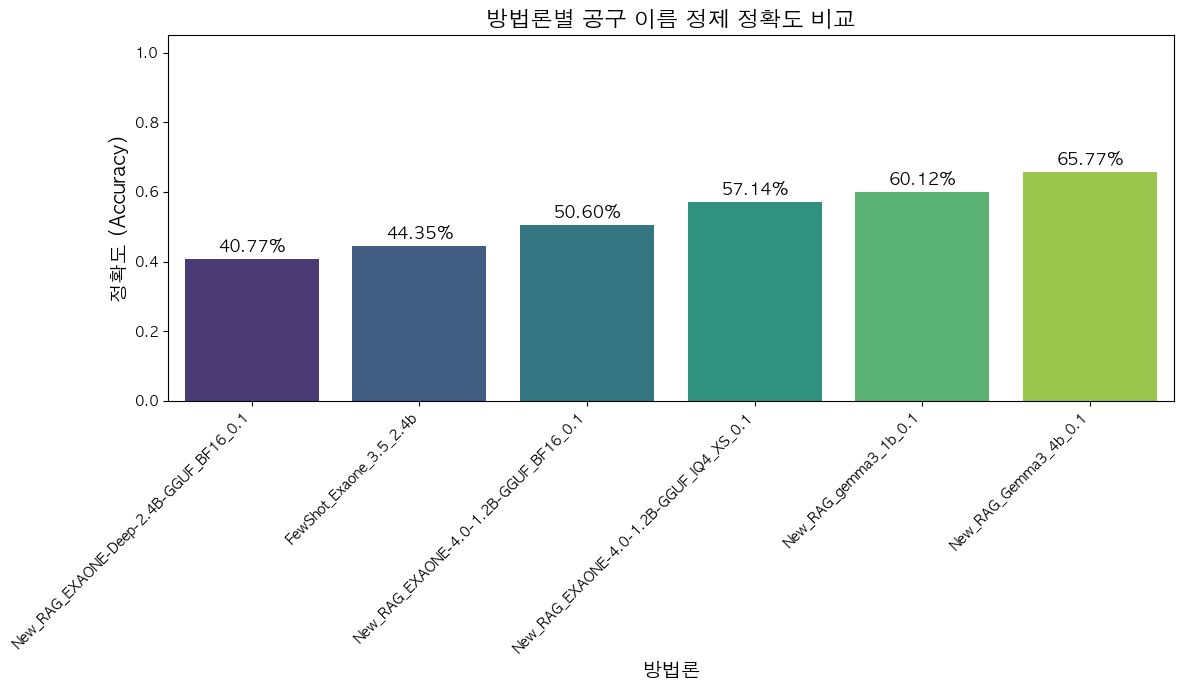


--- 모든 평가 완료 ---


In [193]:
# 4. 막대 그래프 시각화
plt.figure(figsize=(12, 7)) # 가로 폭을 넓혀 폰트 겹침 방지

# hue를 사용하지 않고 barplot 생성 (하나의 카테고리이므로)
barplot = sns.barplot(
    x='Method',
    y='Accuracy',
    data=df_plot,
    palette='viridis'
)
# 그래프에 수치 표시 (소수점 2자리 백분율)
for p in barplot.patches:
    barplot.annotate(f'{p.get_height():.2%}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center',
                     xytext=(0, 9),
                     textcoords='offset points',
                     fontsize=12,
                     fontweight='bold')

plt.title('방법론별 공구 이름 정제 정확도 비교', fontsize=16, fontweight='bold')
plt.ylabel('정확도 (Accuracy)', fontsize=14)
plt.xlabel('방법론', fontsize=14)
plt.xticks(rotation=45, ha='right') # 모델 이름이 길 경우 회전하여 겹침 방지
plt.ylim(0, 1.05) 

# 시각화 결과 보여주기
plt.tight_layout() # 그래프 요소가 잘리지 않도록 레이아웃 자동 조정

plt.savefig('./Data/Pigure/LLM_Accuracy/'+'Accuracy_Camprison_x2')
plt.show()
print("\n--- 모든 평가 완료 ---")

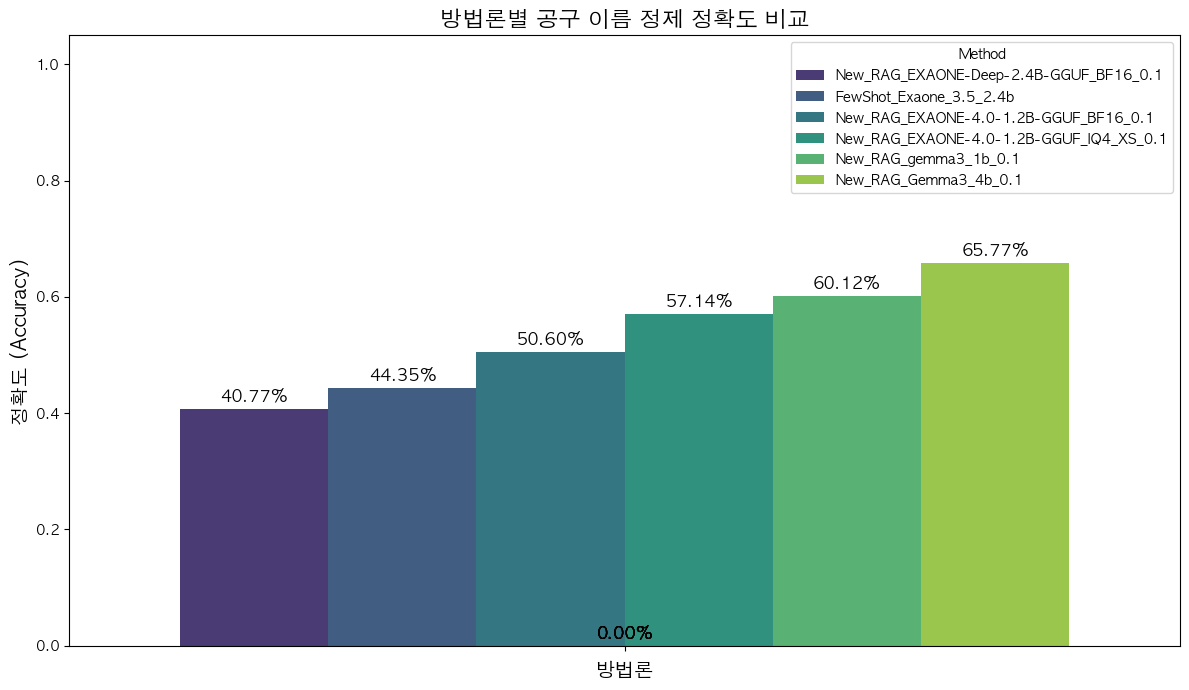


--- 모든 평가 완료 ---


In [194]:
# 4. 막대 그래프 시각화
plt.figure(figsize=(12, 7)) # 가로 폭을 넓혀 폰트 겹침 방지

# hue를 사용하지 않고 barplot 생성 (하나의 카테고리이므로)
barplot = sns.barplot(
    hue='Method',
    y='Accuracy',
    data=df_plot,
    palette='viridis'
)
# 그래프에 수치 표시 (소수점 2자리 백분율)
for p in barplot.patches:
    barplot.annotate(f'{p.get_height():.2%}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center',
                     xytext=(0, 9),
                     textcoords='offset points',
                     fontsize=12,
                     fontweight='bold')

plt.title('방법론별 공구 이름 정제 정확도 비교', fontsize=16, fontweight='bold')
plt.ylabel('정확도 (Accuracy)', fontsize=14)
plt.xlabel('방법론', fontsize=14)
plt.xticks(rotation=45, ha='right') # 모델 이름이 길 경우 회전하여 겹침 방지
plt.ylim(0, 1.05) 

# 시각화 결과 보여주기
plt.tight_layout() # 그래프 요소가 잘리지 않도록 레이아웃 자동 조정

plt.savefig('./Data/Pigure/LLM_Accuracy/'+'Accuracy_Camprison_hue2')
plt.show()
print("\n--- 모든 평가 완료 ---")

# 데이터 유형별 살펴보기

In [24]:
df_ca

,Original_Name,Correct_Name,Brand,Power_Source,Specification,SubCategories,Categories,Dirtydata_Category,Dirtydata_Subtype,근거 (보고서 패턴)
0,180mm 샌더,샌더,NaN,NaN,180mm,샌더/대패,전동공구,정보중복형,속성기입,규격('180mm')이 Original_Name에 포함됨.
1,LED 손전등,손전등,NaN,NaN,LED,기타 일반공구,일반공구,정보중복형,동력원명시,손전등'은 암묵적으로 동력원(충전)을 가짐에도 이름에 동력원이 없음이 플래그됨 (암...
2,경랑몽키(8인치),몽키스패너,NaN,NaN,경량 8인치,몽키/렌치/스패너,일반공구,표준위배형,오탈자,경랑'은 '경량'의 오탈자.
3,고압세척기,고압세척기,NaN,NaN,NaN,기타공구,기타공구,정보중복형,동력원명시,동력원 언급이 없지만 Power_Source가 올바르게 분류됨 (암묵적 규칙 충돌의...
4,바이스플라이어,바이스플라이어,NaN,NaN,NaN,니퍼/펜치/플라이어,일반공구,NaN,NaN,분류표에 명시된 더티 데이터 유형에 해당하지 않는 깨끗한 제품명으로 판단됨.
...,...,...,...,...,...,...,...,...,...,...
3347,휴대용에어펌프,에어펌프,NaN,무선,NaN,기타 생활용품,생활용품,정보중복형,동력원명시,동력원 '에어' 포함.
3348,휴대용유모차,유모차,NaN,NaN,NaN,기타 생활용품,생활용품,NaN,NaN,공구가 아님.
3349,휴대용육각렌치,육각렌치,NaN,NaN,접이식,몽키/렌치/스패너,일반공구,NaN,NaN,명확한 더티 데이터 유형에 해당하지 않음.
3350,흙손,미장칼,NaN,NaN,NaN,도장/페인트,일반공구,NaN,NaN,명확한 더티 데이터 유형에 해당하지 않음.


In [26]:
df_eval_cf = df_eval.copy()
df_eval_cf[['Dirtydata_Category','Dirtydata_Subtype','근거 (보고서 패턴)']] = df_ca[['Dirtydata_Category','Dirtydata_Subtype','근거 (보고서 패턴)']]

In [28]:
df_eval_cf.to_csv(file_path+'New_Evaluation_Dataset.csv',index=False, encoding='utf-8-sig')
df_eval_cf.to_excel(file_path+'New_Evaluation_Dataset.xlsx',index=False)